In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# The Socio-Economic Impact on Education: Predicting State Maturity Exam Scores using Machine Learning

## 1. Problem Statement and Motivation

**Introduction and Context**
Educational outcomes are often viewed as a reflection of a school's quality, but they are deeply intertwined with the broader socio-economic reality of the region. In Bulgaria, the State Maturity Exams (Държавен зрелостен изпит or DZI) serve as the ultimate benchmark for high school education. However, analyzing these grades in a vacuum ignores the macro-economic factors that influence student success, such as regional income disparities, labor market dynamics, and overall living conditions.

**Problem Formulation**
The core objective of this project is to build a Machine Learning regression model that predicts a school's average DZI performance by bridging the gap between micro-level and macro-level data. Specifically, I will investigate whether combining school-specific characteristics (e.g., school profile, cohort size, and historical performance) with district-level socio-economic indicators (e.g., regional income, youth unemployment, and poverty lines) can create a robust predictive model. 

**Project Significance and Objectives**
This approach transforms a simple grade-prediction task into a deeper socio-economic analysis. The primary goals of this project are:
1. **Data Integration:** To successfully merge high-dimensional macro-economic datasets (Regional Profiles) with granular, micro-level educational data (DZI results).
2. **Feature Engineering:** To extract meaningful variables from raw data, such as categorizing school types and utilizing time-series lagged variables for historical performance.
3. **Predictive Modeling:** To train, test, and evaluate various regression algorithms (e.g., Linear Regression, Random Forests) to predict future DZI outcomes.
4. **Interpretability:** To analyze feature importance and understand which socio-economic or school-specific factors carry the most weight in determining educational success.

## 2. Data Loading and Preparation

In [2]:
years = range(2018, 2027)
dzi_frames = []

data_start_mapping = {
    2020: 2, 
    2021: 2, 
    2023: 3
}

for year in years:
    raw_data = pd.read_csv(f'data/dzi-{year}.csv', header=None)
    
    top_rows = raw_data.iloc[0:4].ffill(axis=1).astype(str)
    
    combined_headers = top_rows.apply(lambda x: ' '.join(x).lower())
    
    col_map = {}
    
    for idx, text in enumerate(combined_headers):
        if 'област' in text and 'училище' not in text:
            col_map[idx] = 'District'
        elif 'населено' in text:
            col_map[idx] = 'Settlement'
        elif 'училище' in text and 'профил' not in text:
            col_map[idx] = 'School_Name'
        elif 'админ' in text or 'неиспуо' in text:
            col_map[idx] = 'School_Code'
            
        # Target Variable Extraction
        elif 'бел' in text:
            if any(w in text for w in ['усп', 'оцен']) and 'BEL_Grade' not in col_map.values():
                col_map[idx] = 'BEL_Grade'
            elif any(w in text for w in ['брой', 'бр', 'явили']) and 'BEL_Students_Count' not in col_map.values():
                col_map[idx] = 'BEL_Students_Count'

    yearly_filtered = raw_data[list(col_map.keys())].copy()
    
    yearly_filtered.columns = list(col_map.values())
    yearly_filtered['Year'] = year
    
    start_idx = data_start_mapping.get(year, 1)
    yearly_filtered = yearly_filtered.iloc[start_idx:].copy()
    
    yearly_filtered = yearly_filtered.dropna(subset=['District'])
    
    # THE FIX: Require an exact match to "област" to avoid dropping "софия-област"
    yearly_filtered = yearly_filtered[yearly_filtered['District'].astype(str).str.strip().str.lower() != 'област']
            
    dzi_frames.append(yearly_filtered)

# Consolidate the focused dataset
dzi_full = pd.concat(dzi_frames, ignore_index=True)

# Load Macro-Economic Datasets 
income_data = pd.read_csv('data/E1_25.csv')
labor_data = pd.read_csv('data/E2_25.csv')
edu_data = pd.read_csv('data/S2_25.csv')

In [24]:
dzi_full.head(3)

,District,Settlement,School_Code,School_Name,BEL_Students_Count,BEL_Grade,Year
0,Благоевград,ГР.БАНСКО,102015,Професионална гимназия по електроника и енерге...,38,4.048,2018
1,Благоевград,ГР.БАНСКО,102004,"Професионална лесотехническа гимназия""Никола Й...",39,3.916,2018
2,Благоевград,ГР.БАНСКО,102010,"Гимназия по туризъм ""Алеко Константинов""",18,3.454,2018


In [25]:
income_data.head(3)

District БВП на човек от населението, лв.                             \
      District                             2012     2013     2014     2015   
0  Благоевград                           7533.0   7660.0   7659.0   8013.0   
1       Бургас                           9881.0  10101.0   9449.0  10943.0   
2        Варна                          11631.0  11543.0  12576.0  13285.0   

                                                ...  \
      2016     2017     2018     2019     2020  ...   
0   8449.0   9069.0   9989.0  10627.0  11179.0  ...   
1  12174.0  13283.0  13460.0  14483.0  12351.0  ...   
2  13756.0  14992.0  16537.0  17545.0  17379.0  ...   

  Коефициент на Джини на подоходно неравенство                    \
                                          2021  2022  2023  2024   
0                                         34.1  32.1  27.6  28.6   
1                                         32.6  38.0  29.7  31.7   
2                                         35.9  33.5  33.1  37.1   

  Относителен дял на населението, живеещо под линията на бедността за страната, %  \
                                                                             2019   
0                                               23.9                                
1                                               20.0                                
2                                               18.4                                

                                 
   2020  2021  2022  2023  2024  
0  25.1  19.1  22.9  21.6  19.5  
1  26.5  24.6  22.1  21.0  23.0  
2  22.9  17.3  14.2  14.6  15.2  

[3 rows x 55 columns]

In [26]:
labor_data.head(3)

District  \
      District   
0  Благоевград   
1       Бургас   
2        Варна   

  Относителен дял на населениeто на възраст между 25 и 64 навършени години с висше образование (%)  \
                                                                                              2012   
0                                               17.7                                                 
1                                               18.6                                                 
2                                               26.0                                                 

                                                   ...  \
   2013  2014  2015  2016  2017  2018  2019  2020  ...   
0  18.0  19.6  19.5  19.4  19.9  20.7  21.8  21.1  ...   
1  20.2  18.8  19.3  23.1  24.8  23.6  22.5  24.2  ...   
2  31.4  33.8  30.6  29.9  32.5  29.5  25.3  24.8  ...   

  Дял на населението в трудоспособна възраст,%                                \
                                          2015  2016  2017  2018  2019  2020   
0                                         63.0  62.6  62.1  61.7  61.2  61.1   
1                                         61.6  61.4  60.9  60.5  60.2  60.1   
2                                         62.6  62.4  62.1  61.8  61.7  61.7   

                           
   2021  2022  2023  2024  
0  61.0  59.8  59.5  59.2  
1  60.2  58.9  58.7  58.7  
2  62.0  60.3  60.4  60.5  

[3 rows x 68 columns]

In [27]:
edu_data.head(3)

District Брой на студентите в колежи и университети на 1000 души        \
      District                                                    2012  2013   
0  Благоевград                                               41.3       42.9   
1       Бургас                                               23.6       23.4   
2        Варна                                               69.3       67.2   

                                             ...  \
   2014  2015  2016  2017  2018  2019  2020  ...   
0  41.6  38.5  34.9  32.4  30.8  29.6  29.4  ...   
1  21.7  19.8  17.3  15.9  14.4  14.8  15.1  ...   
2  65.2  63.8  56.9  52.9  51.0  50.9  50.1  ...   

  Дял на децата в детските градини (Групов нетен коефициент на записване)  \
                                                                     2015   
0                                               88.2                        
1                                               84.0                        
2                                               81.2                        

                                                         
   2016  2017  2018  2019  2020  2021  2022  2023  2024  
0  88.8  89.2  88.9  88.3  89.4  89.6  92.6  93.8  95.3  
1  81.5  80.1  79.3  80.0  78.8  79.0  88.4  88.1  89.0  
2  79.8  78.9  79.2  80.1  80.4  81.2  90.3  90.5  90.5  

[3 rows x 74 columns]

### 2.1 Data Cleaning: Addressing Hierarchical Headers

**Problem Identification**
During the initial data exploration of the socio-economic datasets (Income, Labor, Education), we encountered a structural inconsistency common to data converted from Excel. The headers were originally merged cells in the source files, which resulted in a "split-header" format when converted to CSV. Specifically, top-level categories were associated with multiple years, but the CSV export left the columns for the subsequent years empty (represented as `Unnamed` in Pandas).

**Methodology for Resolution**
To preserve the integrity of the data and enable effective merging, we implemented a robust cleaning pipeline:
1. **MultiIndex Loading:** We instructed Pandas to parse the first two rows as a hierarchical header (`header=[0, 1]`), correctly identifying the relationship between categories and specific years.
2. **Forward-Filling Categories:** We utilized a forward-fill (`ffill()`) strategy on the category-level header to propagate the label across the relevant years, ensuring that every column is fully identified by its category and its corresponding year.

In [8]:
def clean_macro_data(file_path):
    # 1. Load the file, keeping the first two rows as the header
    raw_data = pd.read_csv(file_path, header=[0, 1])
    
    # 2. The first column name is currently a tuple like ('Наименование', 'Година')
    # Clean that up to be just 'District'
    raw_data.columns.values[0] = ('District', 'District')
    
    # 3. Forward fill the top-level header (the Category names)
    new_cols = pd.MultiIndex.from_tuples(
        [(c[0] if not 'Unnamed' in c[0] else None, c[1]) for c in raw_data.columns]
    )
    
    # Forward fill the categories
    category_cols = pd.Series(new_cols.get_level_values(0)).ffill()
    year_cols = new_cols.get_level_values(1)
    
    raw_data.columns = pd.MultiIndex.from_arrays([category_cols, year_cols])
    
    return raw_data

# Apply the fix
income_data = clean_macro_data('data/E1_25.csv')
labor_data = clean_macro_data('data/E2_25.csv')
edu_data = clean_macro_data('data/S2_25.csv')

# Verification: Display the first few rows and the column structure
print("Cleaned Data Header Structure:")
display(income_data.head(3))
display(labor_data.head(3))
display(edu_data.head(3))

Cleaned Data Header Structure:


District БВП на човек от населението, лв.                             \
      District                             2012     2013     2014     2015   
0  Благоевград                           7533.0   7660.0   7659.0   8013.0   
1       Бургас                           9881.0  10101.0   9449.0  10943.0   
2        Варна                          11631.0  11543.0  12576.0  13285.0   

                                                ...  \
      2016     2017     2018     2019     2020  ...   
0   8449.0   9069.0   9989.0  10627.0  11179.0  ...   
1  12174.0  13283.0  13460.0  14483.0  12351.0  ...   
2  13756.0  14992.0  16537.0  17545.0  17379.0  ...   

  Коефициент на Джини на подоходно неравенство                    \
                                          2021  2022  2023  2024   
0                                         34.1  32.1  27.6  28.6   
1                                         32.6  38.0  29.7  31.7   
2                                         35.9  33.5  33.1  37.1   

  Относителен дял на населението, живеещо под линията на бедността за страната, %  \
                                                                             2019   
0                                               23.9                                
1                                               20.0                                
2                                               18.4                                

                                 
   2020  2021  2022  2023  2024  
0  25.1  19.1  22.9  21.6  19.5  
1  26.5  24.6  22.1  21.0  23.0  
2  22.9  17.3  14.2  14.6  15.2  

[3 rows x 55 columns]

District  \
      District   
0  Благоевград   
1       Бургас   
2        Варна   

  Относителен дял на населениeто на възраст между 25 и 64 навършени години с висше образование (%)  \
                                                                                              2012   
0                                               17.7                                                 
1                                               18.6                                                 
2                                               26.0                                                 

                                                   ...  \
   2013  2014  2015  2016  2017  2018  2019  2020  ...   
0  18.0  19.6  19.5  19.4  19.9  20.7  21.8  21.1  ...   
1  20.2  18.8  19.3  23.1  24.8  23.6  22.5  24.2  ...   
2  31.4  33.8  30.6  29.9  32.5  29.5  25.3  24.8  ...   

  Дял на населението в трудоспособна възраст,%                                \
                                          2015  2016  2017  2018  2019  2020   
0                                         63.0  62.6  62.1  61.7  61.2  61.1   
1                                         61.6  61.4  60.9  60.5  60.2  60.1   
2                                         62.6  62.4  62.1  61.8  61.7  61.7   

                           
   2021  2022  2023  2024  
0  61.0  59.8  59.5  59.2  
1  60.2  58.9  58.7  58.7  
2  62.0  60.3  60.4  60.5  

[3 rows x 68 columns]

District Брой на студентите в колежи и университети на 1000 души        \
      District                                                    2012  2013   
0  Благоевград                                               41.3       42.9   
1       Бургас                                               23.6       23.4   
2        Варна                                               69.3       67.2   

                                             ...  \
   2014  2015  2016  2017  2018  2019  2020  ...   
0  41.6  38.5  34.9  32.4  30.8  29.6  29.4  ...   
1  21.7  19.8  17.3  15.9  14.4  14.8  15.1  ...   
2  65.2  63.8  56.9  52.9  51.0  50.9  50.1  ...   

  Дял на децата в детските градини (Групов нетен коефициент на записване)  \
                                                                     2015   
0                                               88.2                        
1                                               84.0                        
2                                               81.2                        

                                                         
   2016  2017  2018  2019  2020  2021  2022  2023  2024  
0  88.8  89.2  88.9  88.3  89.4  89.6  92.6  93.8  95.3  
1  81.5  80.1  79.3  80.0  78.8  79.0  88.4  88.1  89.0  
2  79.8  78.9  79.2  80.1  80.4  81.2  90.3  90.5  90.5  

[3 rows x 74 columns]

### 2.2 Data Type Casting and Formatting

An inspection of the newly consolidated `dzi_full` dataset reveals that Pandas has inferred almost all columns as `object` (string) data types. 

This includes our core numerical features, `BEL_Students_Count` and `BEL_Grade`. The reason `BEL_Grade` was cast as an object is due to a data-entry inconsistency in the raw files: some years use a comma as a decimal separator (e.g., `4,048`), while others use a dot (e.g., `3.53`). 

To prevent downstream errors during grouping, merging, and Machine Learning training, we must enforce the correct mathematical data types immediately upon loading. We will also clean the `School_Code` feature to remove any accidental whitespaces, ensuring it acts as a perfect primary key.

In [9]:
# 1. Fix the decimal separator and cast to float
dzi_full['BEL_Grade'] = dzi_full['BEL_Grade'].astype(str).str.replace(',', '.', regex=False)
dzi_full['BEL_Grade'] = pd.to_numeric(dzi_full['BEL_Grade'], errors='coerce')

# 2. Cast student counts to nullable integers
dzi_full['BEL_Students_Count'] = pd.to_numeric(dzi_full['BEL_Students_Count'], errors='coerce').astype('Int64')

# 3. Clean School_Code (Strip whitespaces so '123 456' becomes '123456')
dzi_full['School_Code'] = dzi_full['School_Code'].astype(str).str.replace(' ', '', regex=False)

# Verification
print(dzi_full.dtypes)

# Display a sample to confirm the grades look like proper decimals
display(dzi_full[['School_Name', 'BEL_Students_Count', 'BEL_Grade']].head())

District               object
Settlement             object
School_Code            object
School_Name            object
BEL_Students_Count      Int64
BEL_Grade             float64
Year                    int64
dtype: object


,School_Name,BEL_Students_Count,BEL_Grade
0,Професионална гимназия по електроника и енерге...,38,4.048
1,"Професионална лесотехническа гимназия""Никола Й...",39,3.916
2,"Гимназия по туризъм ""Алеко Константинов""",18,3.454
3,"Професионална гимназия ""Никола Йонков Вапцаров""",17,3.955
4,"Средно училище ""Св.Св.Кирил и Методий""",39,4.336


## 3. Data Integration

### 3.1 Reshaping Macro Data (Wide to Long Format)

**Objective**
Currently, our macro-economic datasets (`income_data`, `labor_data`, and `edu_data`) are in a "wide" format, where separate years exist as distinct columns under each indicator category. However, our main school dataset (`dzi_full`) is organized in a "long" format, where each row represents a specific school's performance in a single year. To merge these datasets seamlessly, we must reshape the macro data so that every row represents a unique combination of a `District` and a single `Year`.

**Methodology**
Instead of using a flat `pd.melt()`, which is structurally difficult to apply to multi-level indexes, we leverage the advanced Pandas `.stack()` method. By stacking the second level of our column hierarchy (the years), we dynamically rotate the time dimensions from columns into rows. This naturally transforms the dataset into a longitudinal layout while preserving the indicator names as top-level features.

In [10]:
def transform_wide_to_long(macro_table):
    district_series = macro_table[('District', 'District')].astype(str).str.strip()
    
    if (district_series == 'България').any():
        bg_index = district_series[district_series == 'България'].index[0]
        filtered_table = macro_table.iloc[:bg_index].copy()
    else:
        filtered_table = macro_table[~district_series.str.contains('Източник', na=False, case=False)].copy()
    
    macro_indexed = filtered_table.set_index(('District', 'District'))
    macro_indexed.index.name = 'District'
    
    long_format_data = macro_indexed.stack(level=1)
    
    long_format_data = long_format_data.reset_index()
    
    long_format_data.columns.values[1] = 'Year'
    
    long_format_data['Year'] = pd.to_numeric(long_format_data['Year'], errors='coerce')
    long_format_data = long_format_data.dropna(subset=['Year'])
    long_format_data['Year'] = long_format_data['Year'].astype(int)
    
    return long_format_data

income_long = transform_wide_to_long(income_data)
labor_long = transform_wide_to_long(labor_data)
edu_long = transform_wide_to_long(edu_data)

/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_28132/409656948.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_format_data = macro_indexed.stack(level=1)
/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_28132/409656948.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_format_data = macro_indexed.stack(level=1)
/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_28132/409656948.py:13: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes 

In [28]:
income_long.head(3)

,District,Year,"БВП на човек от населението, лв.","Средна годишна брутна заплата на наетите по трудово и служебно правоотношение, лв.","Размер на средна пенсия, лв.",Коефициент на Джини на подоходно неравенство,"Относителен дял на населението, живеещо под линията на бедността за страната, %"
0,Благоевград,2012,7533.0,6271.0,NaN,23.3,NaN
1,Благоевград,2013,7660.0,6566.0,NaN,25.5,NaN
2,Благоевград,2014,7659.0,6818.0,280.0,27.6,NaN


In [29]:
labor_long.head(3)

,District,Year,Относителен дял на населениeто на възраст между 25 и 64 навършени години с висше образование (%),Относителен дял на населението на възраст между 25 и 64 навършени години с основно и по-ниско образование (%),"Средногодишен коефициент на безработица, %","Средногодишен коефициент на заетост на населението на 20-64 години, %","Дял на населението в трудоспособна възраст,%"
0,Благоевград,2010,NaN,NaN,NaN,70.4,NaN
1,Благоевград,2011,NaN,NaN,NaN,69.6,NaN
2,Благоевград,2012,17.7,17.5,14.1,70.1,64.3


In [30]:
edu_long.head(3)

,District,Year,Брой на студентите в колежи и университети на 1000 души,"Нетен коефициент на записване на населението V-VII, %","Дял на оценките на ДЗИ по български език и литература под среден 3,00, %","Среден успех на ДЗИ по български език и литература, /6","Среден успех на НВО след 7 клас по математика, в точки/100","Индекс на съответствието между ПОО и заетостта, в точки/100",Дял на децата в детските градини (Групов нетен коефициент на записване)
0,Благоевград,2012,41.3,NaN,5.4,4.19,NaN,NaN,84.8
1,Благоевград,2013,42.9,NaN,3.8,4.29,NaN,NaN,87.8
2,Благоевград,2014,41.6,NaN,2.7,4.41,NaN,NaN,89.3


## 4. Data Standardization and Master Merge

Before merging our high-dimensional macro-economic datasets with our granular DZI records, we must ensure absolute consistency across our primary keys. Real-world data entry is prone to typographical errors, varying formatting conventions, and naming shifts over time. 

**Our Standardization Strategy:**
1. **Micro-Level (Schools):** The `School_Code` feature contains inconsistent whitespace formatting (e.g., `123 456` vs `123456`). We will strip all spaces to create a definitive unique identifier. Then, we will use this cleaned code as an anchor to standardize `School_Name` and `Settlement` across all years, mapping them to their first historical appearance.
2. **Macro-Level (Districts):** The capital city is represented differently across datasets (`'София-Град'` vs `'София'` and `'София (Столица)'`). We will map all variations to a unified `'София'` string and remove external territories (`'Чужбина'`).
3. **Master Merge:** With standardized keys, we will execute sequential left-joins to unify the micro and macro datasets.

In [14]:
# 1. Micro-Level Standardization (School Codes, Names, and Settlements)
reference_names = dzi_full.groupby('School_Code')['School_Name'].first().to_dict()
reference_settlements = dzi_full.groupby('School_Code')['Settlement'].first().to_dict()

dzi_full['School_Name'] = dzi_full['School_Code'].map(reference_names)
dzi_full['Settlement'] = dzi_full['School_Code'].map(reference_settlements)

# 2. Macro-Level Standardization (Districts)
district_map = {
    'София-Град': 'София (Столица)',
    'София-Област': 'София'
}

all_datasets = [dzi_full, income_long, labor_long, edu_long]

for dataset in all_datasets:
    if 'District' in dataset.columns:
        dataset['District'] = dataset['District'].astype(str).str.strip().str.title()
        dataset['District'] = dataset['District'].replace(district_map)
        dataset.drop(dataset[dataset['District'] == 'Чужбина'].index, inplace=True, errors='ignore')
        
    if 'Year' in dataset.columns:
        dataset['Year'] = pd.to_numeric(dataset['Year'], errors='coerce').astype('Int64')

# 3. Strip any accidental duplicates from macro data before merging
macro_datasets = [income_long, labor_long, edu_long]
for macro in macro_datasets:
    macro.drop_duplicates(subset=['District', 'Year'], keep='first', inplace=True)

# 4. Execute the Final Merges
master_data = pd.merge(dzi_full, income_long, on=['District', 'Year'], how='left')
master_data = pd.merge(master_data, labor_long, on=['District', 'Year'], how='left')
master_data = pd.merge(master_data, edu_long, on=['District', 'Year'], how='left')

# Clean artifacts
columns_to_drop = [c for c in master_data.columns if 'Източник' in c or 'Unnamed' in c]
master_data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Automatically cast all unparsed macro data columns from object to float64
metadata_cols = ['District', 'Settlement', 'School_Code', 'School_Name']
for col in master_data.columns:
    if col not in metadata_cols and master_data[col].dtype == 'object':
        master_data[col] = pd.to_numeric(master_data[col], errors='coerce').astype('float64')

print(f"Master Dataset Shape after merge: {master_data.shape}")

Master Dataset Shape after merge: (8655, 24)


## 5. Handling Structural Missingness and Imputation

### 5.1 Temporal Missing Value Diagnostic

Before deciding how to handle missing data, we must first map exactly where the `NaN` values live. Because our dataset is built on a timeline (2018–2026), viewing the total sum of missing values is not enough. We need to generate a year-by-year diagnostic report to determine if the missing data is random, or if it follows a structural, temporal pattern.

In [15]:
missing_report = master_data.groupby('Year').apply(lambda x: x.isna().sum(), include_groups=False).T

# Iterate through each year and print the breakdown
for year in sorted(master_data['Year'].unique()):
    if year in missing_report.columns:
        print(f"\n--- Missing values breakdown for {year} ---")
        print(missing_report[year].to_string())


--- Missing values breakdown for 2018 ---
District                                                                                                           0
Settlement                                                                                                         2
School_Code                                                                                                        0
School_Name                                                                                                        0
BEL_Students_Count                                                                                                 0
BEL_Grade                                                                                                          0
БВП на човек от населението, лв.                                                                                   0
Средна годишна брутна заплата на наетите по трудово и служебно правоотношение, лв.                                 0
Размер на средна пенс

### 5.2 Data Cleaning and Targeted Imputation

Based on the diagnostic report above, the missingness in our dataset is not random. It is structural, driven by macro-economic reporting lags (e.g., 2024 economic data is not yet published) and shifts in government tracking. 

To preserve our core educational data and prevent structural bias in our Machine Learning model, we will apply the following targeted strategies:

1. **Missing Target Variables:** A small number of schools in 2022–2024 are missing the actual DZI target metrics (`BEL_Grade` and `BEL_Students_Count`). Since a regression model cannot train without a target, these specific rows will be dropped.
2. **Structural Anomalies:** There are a handful of rows where the number of students who took the exam is `0`. These represent impossible administrative artifacts and will be purged.
3. **Administrative Outliers:** A few records belong to regional administrative bodies (e.g., РУО - Regional Departments of Education) rather than actual high schools, resulting in a missing `Settlement` designation. These non-school entities will be dropped.
4. **Target Leakage & Discontinued Metrics:** To prevent our model from "cheating", we must remove aggregated district-level grades (e.g., *Среден успех на ДЗИ* and *Дял на оценките... под среден 3,00*), as these mathematically leak our target variable. We will also drop the feature `Индекс на съответствието...`, which is missing for over half of the historical timeline.
5. **Temporal Lags (Imputation):** We will use historical proximity imputation grouped by `District` to mathematically estimate missing macro-economic years based on the closest available local data:
    * **Backward Fill (bfill):** The feature `Относителен дял на населението, живеещо под линията на бедността за страната, %` is missing for 2018. We will estimate this using the earliest available regional data (2019).
    * **Forward Fill (ffill):** The features `БВП на човек от населението, лв.` and `Средна годишна брутна заплата на наетите по трудово и служебно правоотношение, лв.` are missing for 2024. We will estimate these using the most recently available data (2023).

In [16]:
# 1. Track and Drop Missing Target Variables (2022-2024)
missing_targets = master_data[master_data['BEL_Grade'].isna() | master_data['BEL_Students_Count'].isna()]
print(f"Dropping {len(missing_targets)} schools due to missing DZI target variables.")
master_data.dropna(subset=['BEL_Grade', 'BEL_Students_Count'], inplace=True) 

# 2. Filter out schools with zero student counts
zero_student = master_data[(master_data['BEL_Students_Count'] == 0) | (master_data['BEL_Grade'] < 2.0)]
print(f"Dropping {len(zero_student)} school rows with 0 students")
master_data = master_data[(master_data['BEL_Students_Count'] > 0) & (master_data['BEL_Grade'] >= 2.0)].copy()

# 3. Drop the administrative outliers missing a settlement
missing_settlements = master_data[master_data['Settlement'].isna()]
print(f"Dropping {len(missing_settlements)} administrative outliers due to missing Settlement.")
master_data.dropna(subset=['Settlement'], inplace=True) 

# 4. Drop Features with massive structural gaps and Target Leakage
columns_to_drop = [
    'Индекс на съответствието между ПОО и заетостта, в точки/100',
    'Среден успех на ДЗИ по български език и литература, /6',
    'Дял на  оценките на ДЗИ по български език и литература под среден 3,00, %'
]
# Only drop columns that actually exist in the dataframe to avoid errors
existing_drops = [c for c in columns_to_drop if c in master_data.columns]
master_data.drop(columns=existing_drops, inplace=True)
print(f"Dropped {len(existing_drops)} features due to structural gaps or Data Leakage.")

# 5. Impute temporal macro-economic gaps 
columns_to_impute = [
    'БВП на човек от населението, лв.',
    'Средна годишна брутна заплата на наетите по трудово и служебно правоотношение, лв.',
    'Относителен дял на населението, живеещо под линията на бедността за страната, %'
]

for col in columns_to_impute:
    if col in master_data.columns:
        master_data[col] = master_data.groupby('District')[col].ffill().bfill()

print(f"\nFinal Cleaned Dataset Shape: {master_data.shape}")

# Verify the cleaning was successful for the training timeline (2018-2024)
training_check = master_data[master_data['Year'] <= 2024]
remaining_nans = training_check.isna().sum().sum()
print(f"Remaining NaNs in Historical Data (2018-2024): {remaining_nans}")

Dropping 9 schools due to missing DZI target variables.
Dropping 19 school rows with 0 students
Dropping 2 administrative outliers due to missing Settlement.
Dropped 3 features due to structural gaps or Data Leakage.

Final Cleaned Dataset Shape: (8625, 21)
Remaining NaNs in Historical Data (2018-2024): 0


## 6. Out-of-Time (OOT) Holdout Split and Data Quarantining

To build a robust predictive model, we must maintain a "clean-room" environment for training. Our analysis of the merged dataset revealed that macro-economic reporting lags create a structural gap for the 2025 and 2026 academic years. 

**Our Data Partitioning Strategy:**
1. **The Training Set (2018–2024):** We isolate this period as our primary training engine. While 2024 macro-data was sparse, we successfully performed temporal imputation (forward-filling from 2023) to achieve a mathematically complete dataset with zero `NaN` values. This ensures our model trains on a high-density, reliable feature set.
2. **The Holdout Test Set (2025–2026):** We are physically removing the 2025 and 2026 data from our main training pipeline. Because these years lack verified macro-economic reporting, they act as a "blind test" for the model. Keeping them in the main dataset would introduce structural bias and potential noise. Instead, we quarantine them to serve as our final out-of-time (OOT) validation set to test the model's performance on unseen, future scenarios.

In [17]:
# 1. Quarantine the future data (2025 and 2026)
future_data = master_data[master_data['Year'] >= 2025].copy()

# 2. Isolate the historical training data (2018 through 2024)
historical_data = master_data[master_data['Year'] <= 2024].copy()

# 3. Final Verification of the Split
print(f"Historical Training Data Shape: {historical_data.shape}")
print(f"Historical Years: {sorted(historical_data['Year'].unique())}")
print(f"\nFuture Holdout Data Shape: {future_data.shape}")
print(f"Future Years: {sorted(future_data['Year'].unique())}")

# Verify that no NaNs remain in our training engine
missing_in_training = historical_data.isna().sum().sum()
print(f"\nTotal NaN values remaining in Historical Data: {missing_in_training}")
if missing_in_training == 0:
    print("Status: The historical training dataset is mathematically complete and ready for modeling.")

Historical Training Data Shape: (6690, 21)
Historical Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Future Holdout Data Shape: (1935, 21)
Future Years: [np.int64(2025), np.int64(2026)]

Total NaN values remaining in Historical Data: 0
Status: The historical training dataset is mathematically complete and ready for modeling.


## 7. Exploratory Data Analysis (EDA)

With our dataset cleaned and temporally split, we can safely conduct our Exploratory Data Analysis. Our primary objective is to uncover the statistical relationships between regional socio-economic indicators and our target variable: the school's average DZI grade (`BEL_Grade`).

**Crucial Methodology Note:** To prevent data leakage and ensure our final model is evaluated fairly, all EDA is performed **strictly on the `historical_data` (2018–2024)**. The future holdout set remains completely quarantined.

**EDA Objectives:**
1. **Target Distribution:** Understand the spread and central tendency of the DZI grades.
2. **Correlation Analysis:** Identify which macro-economic variables have the strongest linear relationship (positive or negative) with educational outcomes.

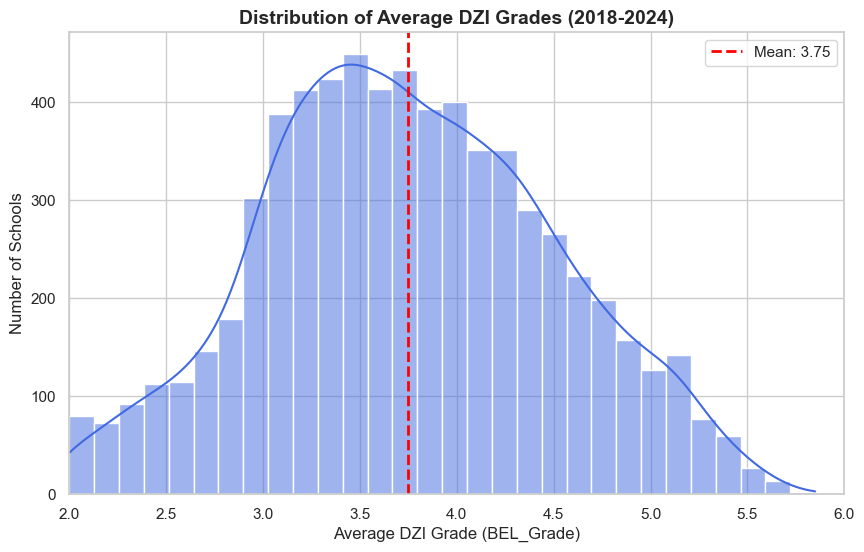

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot the distribution of the target variable
sns.histplot(historical_data['BEL_Grade'], bins=30, kde=True, color='royalblue')

plt.title('Distribution of Average DZI Grades (2018-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Average DZI Grade (BEL_Grade)', fontsize=12)
plt.ylabel('Number of Schools', fontsize=12)

# Calculate descriptive metrics
mean_grade = historical_data['BEL_Grade'].mean()

# Plot metric lines
plt.axvline(mean_grade, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_grade:.2f}")

plt.xlim(2.0, 6.0)
plt.legend()
plt.show()

/var/folders/75/l9c923tx7lq_kr4c7t01qm5c0000gn/T/ipykernel_28132/1489239903.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=focused_corrs.values, y=focused_corrs.index, palette="coolwarm")


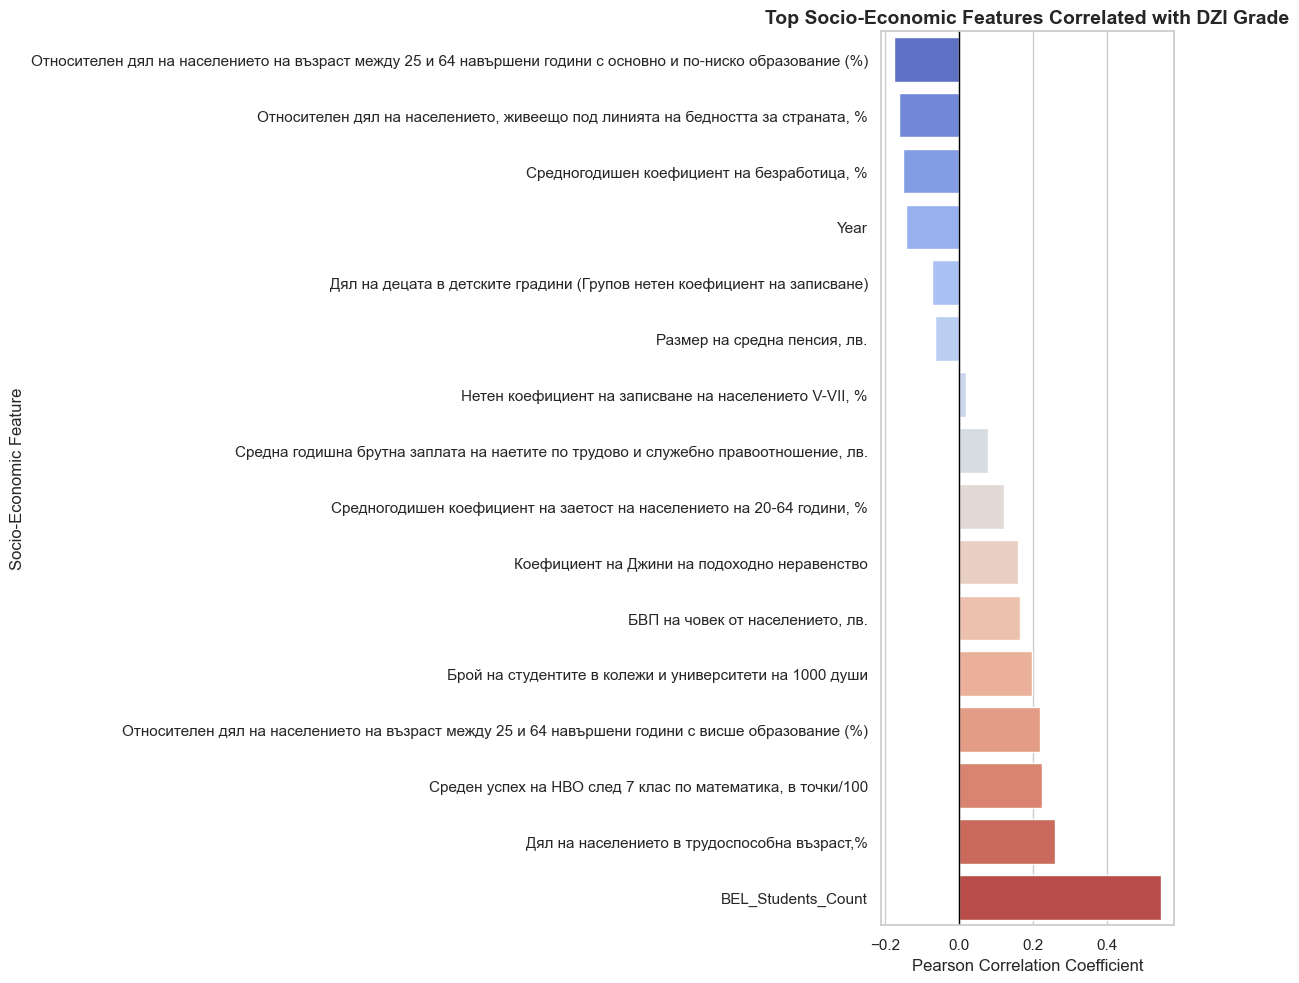

In [19]:
# Isolate all properly cast numeric columns
numeric_cols = historical_data.select_dtypes(include=['float64', 'int64', 'Int64'])

# Calculate correlations specifically with our target metric
correlations = numeric_cols.corr()['BEL_Grade'].drop('BEL_Grade').dropna()
sorted_corrs = correlations.sort_values()

# Isolate the top negative and positive drivers for deep visualization
top_negative = sorted_corrs.head(10)
top_positive = sorted_corrs.tail(10)
focused_corrs = pd.concat([top_negative, top_positive])

plt.figure(figsize=(12, 10))
sns.barplot(x=focused_corrs.values, y=focused_corrs.index, palette="coolwarm")

plt.title('Top Socio-Economic Features Correlated with DZI Grade', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Socio-Economic Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

## 8. Feature Engineering

Feature Engineering bridges the gap between raw data streams and predictive performance. By injecting domain knowledge into our dataset, we help our Machine Learning models learn complex non-linear patterns much faster. 

In this chapter, we will implement two core feature engineering tracks:

### 8.1 Institutional Profile Extraction (Micro-Level)
A school's name in Bulgaria is not just an identifier; it contains structural metadata about its funding, selectivity, and academic focus. We will write an automated text-parsing algorithm to categorize schools into distinct structural types:
* **STEM / Math Academies (`STEM_Math`):** High-selectivity profiled mathematical or natural science high schools (Keywords: ПМГ, МГ, Математическа).
* **Language Academies (`Language`):** High-selectivity profiled foreign language high schools (Keywords: ЕГ, Езикова).
* **Vocational / Technical (`Vocational`):** Professional high schools tracking directly into the labor market (Keywords: ПГ, Професионална, Техникум).
* **General Secondary (`General_Secondary`):** Standard multi-profile comprehensive schools (Keywords: СУ, СОУ, Средно училище).
* **Standard High Schools (`General_High_School`):** Standard gymnasiums or unclassified high schools.

### 8.2 Macro-Economic Interaction Indexes (Macro-Level)
Raw metrics like absolute GDP or nominal average salary do not fully encapsulate regional inequality or educational opportunity. We will engineer three domain-specific compound ratios:
1. **Education Capital Ratio (`Edu_Capital_Ratio`):** The ratio of citizens with higher education to those with primary education or lower. A higher ratio indicates an intellectually robust local environment.
2. **Economic Return Index (`Economic_Return_Index`):** Average regional salary divided by the regional poverty rate. This highlights regions with robust middle classes versus highly unequal economies.
3. **Labor Dynamics Ratio (`Labor_Dynamics_Ratio`):** Regional employment rate relative to regional unemployment rate, tracking the friction and health of the local workforce.

In [48]:
def extract_school_type(school_name):
    name_lower = str(school_name).lower()
    
    # 1. STEM & Mathematical High Schools
    if any(kw in name_lower for kw in ['пмг', 'мг', 'математическа', 'природоматематическа']):
        return 'STEM_Math'
    
    # 2. Language Academies
    elif any(kw in name_lower for kw in ['ег', 'пег', 'езикова']):
        return 'Language'
    
    # 3. Vocational & Technical Schools
    elif any(kw in name_lower for kw in ['пг', 'професионална', 'техникум', 'професионално']):
        return 'Vocational'
    
    # 4. General Secondary Schools (Comprehensive 1st-12th grade)
    elif any(kw in name_lower for kw in ['су', 'соу', 'средно училище']):
        return 'General_Secondary'
    
    # 5. Default Category: Standard High School / Gymnasium
    else:
        return 'General_High_School'

# Process both partitions to maintain strict schema alignment
datasets_to_engineer = [historical_data, future_data]

for df in datasets_to_engineer:
    # Extract the categorical profile
    df['School_Type'] = df['School_Name'].apply(extract_school_type)
    
    # Generate clean One-Hot Encoded flags (0 or 1)
    school_type_dummies = pd.get_dummies(df['School_Type'], prefix='Type').astype(int)
    
    # Merge the encoded flags back into the dataframe
    for col in school_type_dummies.columns:
        df[col] = school_type_dummies[col]

# Print out a verification count of our historical distribution
print("Historical Data School Type Distribution:")
print(historical_data['School_Type'].value_counts())
print(f"Total number of schools: {len(historical_data["School_Type"])}")
print(f"\nNew features added: {[c for c in historical_data.columns if 'Type_' in c]}")

Historical Data School Type Distribution:
School_Type
Vocational             2337
General_Secondary      1965
General_High_School    1939
STEM_Math               230
Language                219
Name: count, dtype: int64
Total number of schools: 6690

New features added: ['Type_General_High_School', 'Type_General_Secondary', 'Type_Language', 'Type_STEM_Math', 'Type_Vocational']


In [45]:
# Define our precise column names as mapped from the national statistics datasets
col_high_edu = 'Относителен дял на населениeто на възраст между 25 и 64 навършени години с висше образование (%)'
col_low_edu = 'Относителен дял на населението на възраст между 25 и 64 навършени години с основно и по-ниско образование (%)'
col_salary = 'Средна годишна брутна заплата на наетите по трудово и служебно правоотношение, лв.'
col_poverty = 'Относителен дял на населението, живеещо под линията на бедността за страната, %'
col_employment = 'Средногодишен коефициент на заетост на населението на 20-64 години, %'
col_unemployment = 'Средногодишен коефициент на безработица, %'

for df in [historical_data, future_data]:
    # 1. Intellectual Capital Ratio (Higher Ed vs Basic/Primary Ed)
    df['Edu_Capital_Ratio'] = df[col_high_edu] / (df[col_low_edu] + 1.0)
    
    # 2. Economic Return Index (Salary adjusted against Poverty Risk)
    df['Economic_Return_Index'] = df[col_salary] / (df[col_poverty] + 1.0)
    
    # 3. Labor Market Friction Dynamics (Employment capacity vs Unemployment overhead)
    df['Labor_Dynamics_Ratio'] = df[col_employment] / (df[col_unemployment] + 1.0)

print("Engineered Macro-Economic Features successfully calculated.")
print(f"Historical Data Shape: {historical_data.shape}")
print(f"Future Data Shape: {future_data.shape}")

# Verify that our tracking metrics look structurally sound and complete
print("\nSample of Engineered Indexes for verification:")
display(historical_data[['District', 'Edu_Capital_Ratio', 'Economic_Return_Index', 'Labor_Dynamics_Ratio']].head())

Engineered Macro-Economic Features successfully calculated.
Historical Data Shape: (6690, 30)
Future Data Shape: (1935, 30)

Sample of Engineered Indexes for verification:


,District,Edu_Capital_Ratio,Economic_Return_Index,Labor_Dynamics_Ratio
0,Благоевград,1.024752,362.409639,7.092593
1,Благоевград,1.024752,362.409639,7.092593
2,Благоевград,1.024752,362.409639,7.092593
3,Благоевград,1.024752,362.409639,7.092593
4,Благоевград,1.024752,362.409639,7.092593


In [52]:
translation_dict = {
    # Macro-Economic Indicators
    'БВП на човек от населението, лв.': 'gdp_per_capita',
    'Средна годишна брутна заплата на наетите по трудово и служебно правоотношение, лв.': 'avg_annual_salary',
    'Размер на средна пенсия, лв.': 'avg_pension',
    'Коефициент на Джини на подоходно неравенство': 'gini_coefficient',
    'Относителен дял на населението, живеещо под линията на бедността за страната, %': 'poverty_rate',
    
    # Demographics & Education Infrastructure
    'Относителен дял на населениeто на възраст между 25 и 64 навършени години с висше образование (%)': 'share_higher_edu',
    'Относителен дял на населението на възраст между 25 и 64 навършени години с основно и по-ниско образование (%)': 'share_primary_or_lower_edu',
    'Средногодишен коефициент на безработица, %': 'unemployment_rate',
    'Средногодишен коефициент на заетост на населението на 20-64 години, %': 'employment_rate',
    'Дял на населението в трудоспособна възраст,%': 'working_age_share',
    'Брой на студентите в колежи и университети на 1000 души': 'university_students_per_1000',
    'Нетен коефициент на записване на населението V-VII, %': 'net_enrollment_5th_7th_grade',
    'Среден успех на НВО след 7 клас по математика, в точки/100': 'avg_math_7th_grade_points',
    'Дял на децата в детските градини (Групов нетен коефициент на записване)': 'kindergarten_enrollment_rate'
}

# Apply the translation to both datasets
for df in [historical_data, future_data]:
    df.rename(columns=translation_dict, inplace=True)

print("All feature names translated to English snake_case.")
print("\nFinal Column List for Machine Learning:")
print(list(historical_data.columns))

All feature names translated to English snake_case.

Final Column List for Machine Learning:
['District', 'Settlement', 'School_Code', 'School_Name', 'BEL_Students_Count', 'BEL_Grade', 'Year', 'gdp_per_capita', 'avg_annual_salary', 'avg_pension', 'gini_coefficient', 'poverty_rate', 'share_higher_edu', 'share_primary_or_lower_edu', 'unemployment_rate', 'employment_rate', 'working_age_share', 'university_students_per_1000', 'net_enrollment_5th_7th_grade', 'avg_math_7th_grade_points', 'kindergarten_enrollment_rate', 'School_Type', 'Type_General_High_School', 'Type_General_Secondary', 'Type_Language', 'Type_STEM_Math', 'Type_Vocational', 'Edu_Capital_Ratio', 'Economic_Return_Index', 'Labor_Dynamics_Ratio']


## 9. Feature Scaling and Final Preparation

Before transitioning into the model training phase, the datasets must be converted into purely mathematical matrices. This involves isolating our target variable, stripping away human-readable metadata, and normalizing the scale of our numeric features.

### 9.1 Matrix Separation ($X$ and $y$)
We will separate our historical dataset into the feature matrix ($X\_train$) and the target vector ($y\_train$). The future dataset ($X\_future$) will be processed identically but will lack a target vector, as these are the 2025–2026 predictions our model should make.

**Dropped Metadata Columns:**
* `District`, `Settlement`, `School_Code`, `School_Name`: These are unique identifiers that carry no mathematical predictive weight and would cause massive dimensionality issues. 
* `School_Type`: This was the raw string column we used to generate our One-Hot Encoded `Type_` flags. It is now redundant.

### 9.2 Feature Scaling (Standardization)
Our features currently exist on vastly different scales (e.g., GDP in thousands vs. percentages in the 0-100 range vs. engineered ratios between 0 and 5). To ensure balanced gradient descent and feature importance calculation, we will apply **Z-score Standardization** using `StandardScaler`. 

**Critical Anti-Leakage Protocol:** The Scaler will be `fit` **strictly on the historical training data ($X\_train$)**. The future holdout data ($X\_future$) will only be `transformed` using the historical distribution parameters.

In [62]:
# 1. Separate target variable and drop descriptive metadata columns
metadata_cols = ['District', 'Settlement', 'School_Code', 'School_Name', 'School_Type']
target_col = 'BEL_Grade'

# Isolate historical features and targets
y_historical = historical_data[target_col].copy()
X_historical = historical_data.drop(columns=metadata_cols + [target_col]).copy()

# Isolate future features (unlabeled/quarantined prediction target)
X_future_raw = future_data.drop(columns=metadata_cols + [target_col], errors='ignore').copy()

# 2. Create a split within the Historical Data (80% Train, 20% Val)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_historical, y_historical, test_size=0.2, random_state=42
)

# 3. Initialize the Scaler
scaler = StandardScaler()

# 4. Critical Anti-Leakage Scaling Protocol:
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
X_val = pd.DataFrame(scaler.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)
X_future = pd.DataFrame(scaler.transform(X_future_raw), columns=X_future_raw.columns, index=X_future_raw.index)

# 5. Pipeline Shape Sanity Check
print("Data Preparation, Internal Splitting, and Scaling Complete!")
print("-" * 60)
print(f"Internal Training Features (X_train):   {X_train.shape}  <- Used to train models")
print(f"Internal Validation Features (X_val):   {X_val.shape}  <- Used to test model accuracy")
print(f"Future Holdout Features (X_future):     {X_future.shape}  <- Quarantined blind final test")
print("-" * 60)
print(f"Training Targets Vector (y_train):      {y_train.shape}")
print(f"Validation Targets Vector (y_val):      {y_val.shape}")

Data Preparation, Internal Splitting, and Scaling Complete!
------------------------------------------------------------
Internal Training Features (X_train):   (5352, 24)  <- Used to train models
Internal Validation Features (X_val):   (1338, 24)  <- Used to test model accuracy
Future Holdout Features (X_future):     (1935, 24)  <- Quarantined blind final test
------------------------------------------------------------
Training Targets Vector (y_train):      (5352,)
Validation Targets Vector (y_val):      (1338,)
